# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** [Rizky Ramdhani]
- **Email:** [kikidewadota11@gmail.com]
- **ID Dicoding:** [kiki_dewadota11ghcw]

## Menentukan Pertanyaan Bisnis

Pada proyek ini saya menggunakan **E-Commerce Public Dataset (Olist Brazilian E-Commerce)** yang berisi data transaksi e-commerce di Brazil periode 2016–2018. Sebelum melakukan analisis, saya merumuskan pertanyaan bisnis yang akan dijawab dengan mengikuti prinsip **SMART** (*Specific, Measurable, Action-Oriented, Relevant, Time-bound*).

**Pertanyaan 1:** Bagaimana **tren jumlah pesanan dan total revenue bulanan** di Olist selama periode **September 2016 hingga Agustus 2018**, serta **kategori produk apa** yang berkontribusi paling besar terhadap revenue?

> - *Specific*: Fokus pada jumlah pesanan, total revenue (BRL), dan kontribusi kategori produk.
> - *Measurable*: Dapat diukur dalam jumlah pesanan dan nilai BRL (R$).
> - *Action-Oriented*: Hasil membantu manajemen menentukan strategi stok dan promosi pada kategori unggulan.
> - *Relevant*: Tren dan kategori unggulan adalah dasar perencanaan bisnis e-commerce.
> - *Time-bound*: Periode dibatasi September 2016 hingga Agustus 2018 (data yang lengkap).

**Pertanyaan 2:** **State (negara bagian) di Brazil mana** yang memberikan kontribusi revenue tertinggi pada periode 2016–2018, dan bagaimana **segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary)** untuk mengidentifikasi pelanggan bernilai tinggi?

> - *Specific*: Fokus pada distribusi revenue per state dan segmentasi RFM pelanggan.
> - *Measurable*: Diukur dengan total revenue per state dan skor RFM tiap pelanggan.
> - *Action-Oriented*: Hasil membantu menentukan target pasar regional dan strategi customer retention.
> - *Relevant*: Krusial untuk strategi ekspansi geografis dan personalisasi marketing.
> - *Time-bound*: Periode 2016–2018.

## Import Semua Packages/Library yang Digunakan

Pada bagian ini, saya memuat seluruh *library* yang dibutuhkan dalam proses analisis, mulai dari manipulasi data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`), hingga utilitas tanggal (`datetime`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Library berhasil diimpor.')

Library berhasil diimpor.


## Data Wrangling

Tahap **Data Wrangling** terdiri atas tiga sub-tahap berurutan: **Gathering Data** (mengumpulkan data ke DataFrame), **Assessing Data** (menilai kualitas data), dan **Cleaning Data** (membersihkan masalah yang ditemukan).

### Gathering Data

Pada tahap ini, saya mengumpulkan dan memuat seluruh berkas CSV dari E-Commerce Public Dataset ke dalam DataFrame pandas. Dataset terdiri atas beberapa berkas yang saling berelasi melalui *foreign key* seperti `order_id`, `customer_id`, dan `product_id`.

In [2]:
# Memuat seluruh dataset dari folder data
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
sellers_df = pd.read_csv('data/sellers_dataset.csv')
geolocation_df = pd.read_csv('data/geolocation_dataset.csv')
category_translation_df = pd.read_csv('data/product_category_name_translation.csv')

print('Seluruh dataset berhasil dimuat.')
print(f'customers_df          : {customers_df.shape}')
print(f'orders_df             : {orders_df.shape}')
print(f'order_items_df        : {order_items_df.shape}')
print(f'order_payments_df     : {order_payments_df.shape}')
print(f'order_reviews_df      : {order_reviews_df.shape}')
print(f'products_df           : {products_df.shape}')
print(f'sellers_df            : {sellers_df.shape}')
print(f'geolocation_df        : {geolocation_df.shape}')
print(f'category_translation  : {category_translation_df.shape}')

Seluruh dataset berhasil dimuat.
customers_df          : (99441, 5)
orders_df             : (99441, 8)
order_items_df        : (112650, 7)
order_payments_df     : (103886, 5)
order_reviews_df      : (99224, 7)
products_df           : (32951, 9)
sellers_df            : (3095, 4)
geolocation_df        : (1000163, 5)
category_translation  : (71, 2)


**Insight:**
- Dataset terdiri dari 9 tabel relasional dengan total lebih dari 1,3 juta baris (didominasi oleh `geolocation_df`).
- Tabel utama adalah `orders_df` dan `customers_df` dengan masing-masing 99.441 baris yang merepresentasikan total pesanan unik.
- Tabel `order_items_df` (112.650 baris) menunjukkan bahwa beberapa pesanan berisi lebih dari satu item.

### Assessing Data

Pada tahap ini, saya menilai kualitas tiap dataset untuk mengidentifikasi *missing value*, *duplicate*, *invalid value*, *inaccurate value*, dan *inconsistent value*. Saya akan memeriksa tiap tabel utama satu per satu.

#### a) Assessing `orders_df`

In [3]:
# Cek struktur, tipe data, dan nilai null pada orders_df
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [4]:
# Cek missing values
print('Missing values pada orders_df:')
print(orders_df.isnull().sum())
print(f'\nDuplicate rows: {orders_df.duplicated().sum()}')

Missing values pada orders_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate rows: 0


In [5]:
# Cek distribusi order_status
print('Distribusi order_status:')
print(orders_df['order_status'].value_counts())

Distribusi order_status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Temuan pada `orders_df`:**
1. **Tipe data tidak sesuai:** Kolom `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, dan `order_estimated_delivery_date` masih bertipe **object (string)**, padahal seharusnya bertipe **datetime** agar dapat dilakukan analisis time series.
2. **Missing value:** Terdapat *missing value* pada kolom waktu pengiriman (`order_approved_at`: 160, `order_delivered_carrier_date`: 1.783, `order_delivered_customer_date`: 2.965). *Missing value* ini sebagian besar berasal dari pesanan yang tidak berstatus `delivered` (seperti `canceled`, `unavailable`, dll.) — sehingga **wajar secara bisnis**.

#### b) Assessing `products_df`

In [6]:
print('Missing values pada products_df:')
print(products_df.isnull().sum())
print(f'\nDuplicate rows: {products_df.duplicated().sum()}')

Missing values pada products_df:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



Duplicate rows: 0


**Temuan pada `products_df`:**
- Terdapat 610 *missing value* pada `product_category_name` (dan kolom turunannya), serta 2 *missing value* pada dimensi/berat produk.
- Untuk kolom `product_category_name` yang kosong, saya akan mengisinya dengan label `'unknown'` agar produk tersebut tetap dapat ikut dianalisis namun tidak dimasukkan ke kategori manapun.

#### c) Assessing `geolocation_df`

In [7]:
print(f'Shape: {geolocation_df.shape}')
print(f'Duplicate rows: {geolocation_df.duplicated().sum():,}')
print(f'Missing values: {geolocation_df.isnull().sum().sum()}')

Shape: (1000163, 5)


Duplicate rows: 261,831
Missing values: 0


**Temuan pada `geolocation_df`:**
- Terdapat **261.831 baris duplikat** dari total 1.000.163 baris. Duplikat akan dihapus agar tidak menyebabkan bias pada analisis geospasial.

#### d) Assessing `customers_df`, `order_items_df`, dan `order_reviews_df`

In [8]:
for name, df in [('customers_df', customers_df),
                  ('order_items_df', order_items_df),
                  ('order_reviews_df', order_reviews_df)]:
    print(f'=== {name} ===')
    print(f'Shape       : {df.shape}')
    print(f'Missing     : {df.isnull().sum().sum()}')
    print(f'Duplicates  : {df.duplicated().sum()}')
    print()

=== customers_df ===
Shape       : (99441, 5)
Missing     : 0
Duplicates  : 0

=== order_items_df ===
Shape       : (112650, 7)
Missing     : 0
Duplicates  : 0

=== order_reviews_df ===
Shape       : (99224, 7)
Missing     : 145903
Duplicates  : 0



**Temuan tambahan:**
- `customers_df` bersih tanpa missing value maupun duplikat.
- `order_items_df` juga bersih.
- `order_reviews_df` memiliki *missing value* pada `review_comment_title` dan `review_comment_message` — ini **wajar** karena pelanggan tidak diwajibkan menulis komentar saat memberi rating.

**Ringkasan masalah yang akan dibersihkan pada tahap Cleaning Data:**
1. Mengubah tipe data kolom timestamp di `orders_df` dari *object* menjadi *datetime*.
2. Menghapus baris duplikat di `geolocation_df`.
3. Mengisi *missing value* pada `product_category_name` di `products_df` dengan `'unknown'`.

### Cleaning Data

Pada tahap ini, saya membersihkan masalah-masalah yang ditemukan di tahap *Assessing Data*.

#### Pembersihan 1 — Konversi tipe data tanggal pada `orders_df`

In [9]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

# Verifikasi
print(orders_df[date_cols].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


#### Pembersihan 2 — Menghapus duplikat pada `geolocation_df`

In [10]:
before = len(geolocation_df)
geolocation_df = geolocation_df.drop_duplicates().reset_index(drop=True)
after = len(geolocation_df)
print(f'Sebelum: {before:,} baris')
print(f'Sesudah: {after:,} baris')
print(f'Dihapus: {before - after:,} baris duplikat')

Sebelum: 1,000,163 baris
Sesudah: 738,332 baris
Dihapus: 261,831 baris duplikat


#### Pembersihan 3 — Mengisi *missing value* pada `product_category_name`

In [11]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')
print(f"Missing values pada product_category_name: {products_df['product_category_name'].isnull().sum()}")

Missing values pada product_category_name: 0


#### Pembersihan 4 — Konversi tipe tanggal pada `order_items_df` dan `order_reviews_df`

In [12]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])
order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'])
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(order_reviews_df['review_answer_timestamp'])
print('Konversi tanggal selesai.')

Konversi tanggal selesai.


**Insight:**
- Seluruh kolom waktu pada tiga DataFrame utama sekarang sudah bertipe `datetime` sehingga dapat digunakan untuk analisis time series (tren bulanan, recency RFM, dsb).
- Duplikat pada `geolocation_df` telah dihapus, mengurangi data dari 1.000.163 menjadi sekitar 738.000 baris unik.
- Produk dengan kategori tidak diketahui kini ditandai eksplisit dengan label `'unknown'`, mempertahankan integritas analisis tanpa membuang data.

## Exploratory Data Analysis (EDA)

Pada tahap ini, saya melakukan eksplorasi data untuk memahami pola, distribusi, dan ringkasan statistik yang relevan dengan kedua pertanyaan bisnis. Saya akan banyak melakukan **grouping** dan **agregasi** untuk mendapatkan insight awal.

### Persiapan: Membuat DataFrame gabungan

Untuk menjawab pertanyaan bisnis, saya perlu menggabungkan beberapa tabel agar setiap baris berisi informasi pesanan, item, pelanggan, dan kategori produk.

In [13]:
# Filter pesanan dengan status delivered (transaksi yang sukses dan revenue diakui)
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Jumlah pesanan delivered: {len(delivered_orders):,}')

# Gabungkan: orders <- order_items <- products <- category translation <- customers
df = (delivered_orders
      .merge(order_items_df, on='order_id', how='inner')
      .merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
      .merge(category_translation_df, on='product_category_name', how='left')
      .merge(customers_df, on='customer_id', how='left'))

# Untuk product yang category_name = 'unknown', isi english juga 'unknown'
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# Kolom tanggal turunan untuk analisis bulanan
df['order_year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

print(f'Shape DataFrame gabungan: {df.shape}')
df.head(3)

Jumlah pesanan delivered: 96,478


Shape DataFrame gabungan: (110197, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018-08


### EDA #1: Statistik Deskriptif Numerik

In [14]:
# Ringkasan statistik untuk kolom numerik utama
df[['price', 'freight_value']].describe()

,price,freight_value
count,110197.000000,110197.000000
mean,119.980563,19.948598
std,182.299446,15.698136
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.900000,16.260000
75%,134.170000,21.150000
max,6735.000000,409.680000


**Insight statistik harga:**
- Harga rata-rata produk per item adalah sekitar **R$ 120**, namun terdistribusi sangat *skewed* ke kanan (75% data berada di bawah ~R$ 135 sementara nilai maksimum mencapai ribuan reais).
- *Freight value* (ongkir) rata-rata sekitar **R$ 20** per item, dengan standar deviasi yang relatif kecil — pengiriman cukup terjangkau untuk mayoritas pesanan.

### EDA #2: Tren Pesanan Bulanan (untuk Pertanyaan 1)

In [15]:
monthly = df.groupby('order_year_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).reset_index()
monthly['order_year_month'] = pd.to_datetime(monthly['order_year_month'])
monthly = monthly.sort_values('order_year_month').reset_index(drop=True)
monthly

,order_year_month,total_orders,total_revenue
0,2016-09-01,1,134.97
1,2016-10-01,265,40325.11
2,2016-12-01,1,10.90
3,2017-01-01,750,111798.36
4,2017-02-01,1653,234223.40
5,2017-03-01,2546,359198.85
6,2017-04-01,2303,340669.68
7,2017-05-01,3546,489338.25
8,2017-06-01,3135,421923.37
9,2017-07-01,3872,481604.52


**Insight tren bulanan:**
- Pertumbuhan pesanan sangat signifikan dari Oktober 2016 (~265 pesanan) ke pertengahan 2018 (~6.000–6.700 pesanan/bulan).
- Bulan **November 2017** menjadi *peak* dengan lonjakan jumlah pesanan dan revenue — ini berhubungan dengan **Black Friday 2017** yang jatuh di tanggal 24 November.
- Data Desember 2016 hanya berisi 1 pesanan (anomali) — kemungkinan data belum lengkap di awal periode operasional Olist.
- Setelah Black Friday 2017, jumlah pesanan stabil di kisaran 5.500–6.800 per bulan, menandakan basis pelanggan yang lebih matang.

### EDA #3: Top Kategori Produk berdasarkan Revenue

In [16]:
category_perf = df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).sort_values('total_revenue', ascending=False)
category_perf.head(10)

,total_orders,total_revenue,avg_price
product_category_name_english,,,
health_beauty,8647,1233131.72,130.283330
watches_gifts,5495,1166176.98,199.040276
bed_bath_table,9272,1023434.76,93.438762
sports_leisure,7530,954852.55,113.254958
computers_accessories,6530,888724.61,116.264339
furniture_decor,6307,711927.69,87.246040
housewares,5743,615628.69,90.600249
cool_stuff,3559,610204.10,164.121598
auto,3810,578966.65,139.847017


**Insight top kategori:**
- Lima kategori dengan revenue tertinggi adalah **health_beauty**, **watches_gifts**, **bed_bath_table**, **sports_leisure**, dan **computers_accessories**.
- Kategori `health_beauty` memimpin dengan revenue lebih dari R$ 1,2 juta — kombinasi volume tinggi dan harga rata-rata yang moderat.
- Kategori `watches_gifts` memiliki **harga rata-rata tertinggi** di antara top 5, menandakan margin kotor yang lebih besar per item.

### EDA #4: Distribusi Revenue per State (untuk Pertanyaan 2)

In [17]:
state_perf = df.groupby('customer_state').agg(
    total_customers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_revenue', ascending=False)
state_perf.head(10)

,total_customers,total_orders,total_revenue
customer_state,,,
SP,39156,40501,5067633.16
RJ,11917,12350,1759651.13
MG,11001,11354,1552481.83
RS,5168,5345,728897.47
PR,4769,4923,666063.51
SC,3449,3546,507012.13
BA,3158,3256,493584.14
DF,2019,2080,296498.41
GO,1895,1957,282836.70


**Insight distribusi geografis:**
- **São Paulo (SP)** mendominasi dengan revenue lebih dari **R$ 5 juta** (sekitar 38% dari total revenue) dan ~39 ribu pelanggan unik.
- **Rio de Janeiro (RJ)** dan **Minas Gerais (MG)** menempati posisi kedua dan ketiga, namun selisih dengan SP sangat jauh.
- Tiga state teratas (SP, RJ, MG) menyumbang lebih dari **62% revenue total** — terdapat ketimpangan distribusi yang sangat kuat ke wilayah Tenggara Brazil.

### EDA #5: Metode Pembayaran

In [18]:
payment_summary = order_payments_df.groupby('payment_type').agg(
    total_transactions=('order_id', 'count'),
    total_value=('payment_value', 'sum'),
    avg_value=('payment_value', 'mean')
).sort_values('total_value', ascending=False)
payment_summary

,total_transactions,total_value,avg_value
payment_type,,,
credit_card,76795,12542084.19,163.319021
boleto,19784,2869361.27,145.034435
voucher,5775,379436.87,65.703354
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000


**Insight metode pembayaran:**
- **Credit card** mendominasi (~74% transaksi) dengan rata-rata nilai transaksi tertinggi.
- **Boleto** (sistem pembayaran tunai khas Brazil) menjadi metode kedua, mencerminkan adopsi pembayaran non-kartu yang masih signifikan.
- Voucher dan debit card kontribusinya kecil.

## Visualization & Explanatory Analysis

Pada tahap ini, saya membuat visualisasi yang menjawab langsung kedua pertanyaan bisnis. Setiap visualisasi dirancang dengan **prinsip integritas data**:
- *Lie Factor* mendekati 1 (proporsi visual sebanding dengan data).
- *Data-Ink Ratio* tinggi: minim *chart-junk*, fokus pada elemen yang merepresentasikan data.
- Sumbu Y dimulai dari 0 untuk *bar chart* agar tidak menyesatkan.
- Label, judul, dan keterangan unit selalu disertakan.

### Pertanyaan 1: Tren Pesanan & Revenue Bulanan, serta Kategori Unggulan

#### Visualisasi 1.1 — Tren Jumlah Pesanan & Revenue Bulanan

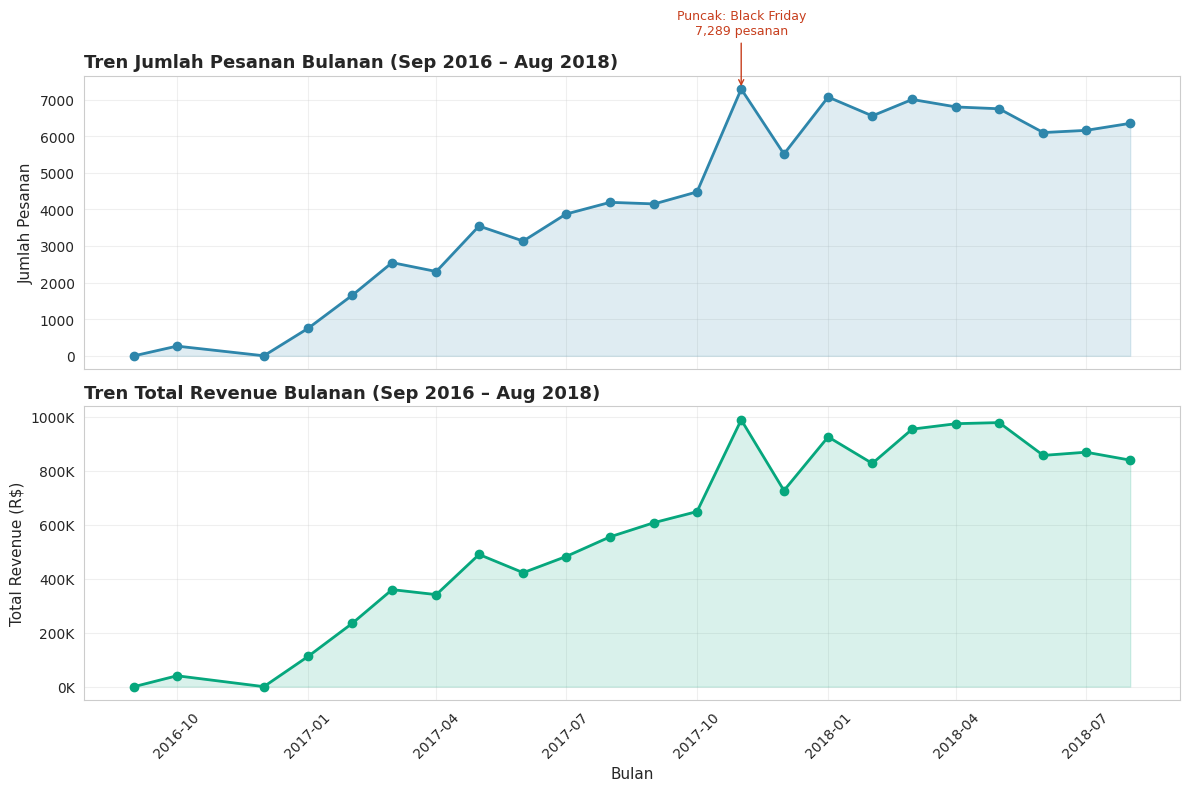

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Sub-plot 1: Jumlah pesanan
axes[0].plot(monthly['order_year_month'], monthly['total_orders'],
             marker='o', linewidth=2, color='#2E86AB')
axes[0].fill_between(monthly['order_year_month'], monthly['total_orders'],
                     alpha=0.15, color='#2E86AB')
axes[0].set_ylabel('Jumlah Pesanan', fontsize=11)
axes[0].set_title('Tren Jumlah Pesanan Bulanan (Sep 2016 – Aug 2018)',
                  fontsize=13, fontweight='bold', loc='left')
axes[0].grid(True, alpha=0.3)
# Anotasi Black Friday 2017
peak = monthly.loc[monthly['total_orders'].idxmax()]
axes[0].annotate(f'Puncak: Black Friday\n{int(peak["total_orders"]):,} pesanan',
                 xy=(peak['order_year_month'], peak['total_orders']),
                 xytext=(peak['order_year_month'], peak['total_orders'] + 1500),
                 ha='center', fontsize=9, color='#C73E1D',
                 arrowprops=dict(arrowstyle='->', color='#C73E1D'))

# Sub-plot 2: Revenue
axes[1].plot(monthly['order_year_month'], monthly['total_revenue'],
             marker='o', linewidth=2, color='#06A77D')
axes[1].fill_between(monthly['order_year_month'], monthly['total_revenue'],
                     alpha=0.15, color='#06A77D')
axes[1].set_ylabel('Total Revenue (R$)', fontsize=11)
axes[1].set_xlabel('Bulan', fontsize=11)
axes[1].set_title('Tren Total Revenue Bulanan (Sep 2016 – Aug 2018)',
                  fontsize=13, fontweight='bold', loc='left')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Penjelasan:** Grafik di atas menampilkan tren bulanan jumlah pesanan (atas) dan total revenue dalam BRL (bawah). Pola pertumbuhan yang konsisten terlihat sepanjang 2017 hingga awal 2018, mencapai *peak* pada **November 2017** (Black Friday). Setelah itu, jumlah pesanan stabil di kisaran 5.500–6.800/bulan, mengindikasikan platform telah mencapai fase *steady-state*.

#### Visualisasi 1.2 — Top 10 Kategori Produk berdasarkan Revenue

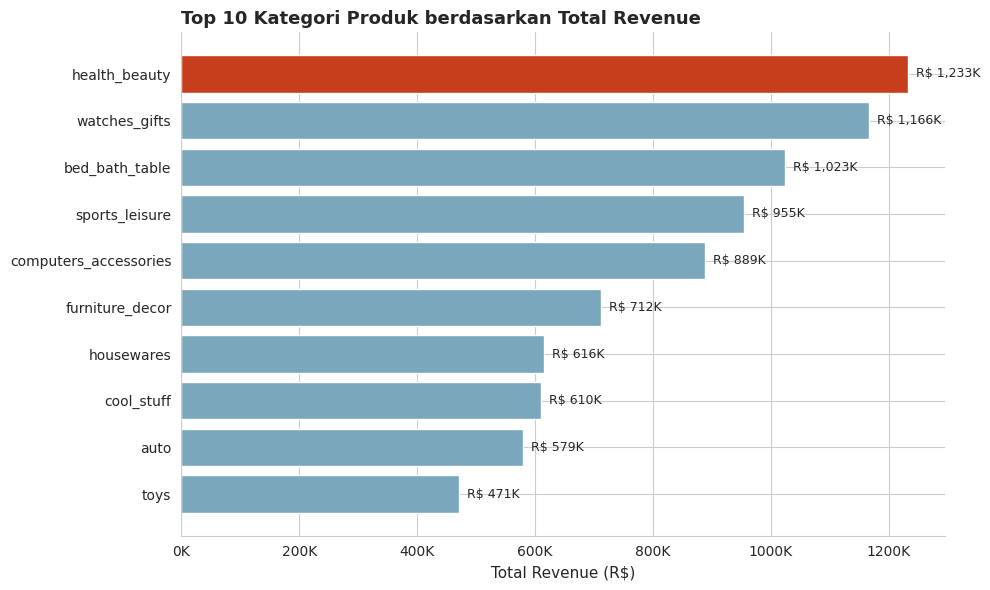

In [20]:
top10_cat = category_perf.head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C73E1D'] + ['#7BA7BC'] * 9   # highlight #1 only
bars = ax.barh(top10_cat['product_category_name_english'][::-1],
               top10_cat['total_revenue'][::-1],
               color=colors[::-1])
ax.set_xlabel('Total Revenue (R$)', fontsize=11)
ax.set_title('Top 10 Kategori Produk berdasarkan Total Revenue',
             fontsize=13, fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Anotasi nilai pada tiap bar
for bar, val in zip(bars, top10_cat['total_revenue'][::-1]):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f'  R$ {val/1000:,.0f}K', va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Penjelasan:** Kategori **`health_beauty`** menjadi kontributor revenue tertinggi (di-*highlight* warna merah), diikuti **`watches_gifts`** dan **`bed_bath_table`**. Lima kategori teratas masing-masing membukukan revenue di atas R$ 880 ribu, sementara kategori di luar top-10 berkontribusi jauh lebih kecil. Ini mengindikasikan *long-tail distribution* yang umum dalam e-commerce.

### Pertanyaan 2: Distribusi Geografis & Segmentasi RFM Pelanggan

#### Visualisasi 2.1 — Top 10 State berdasarkan Revenue

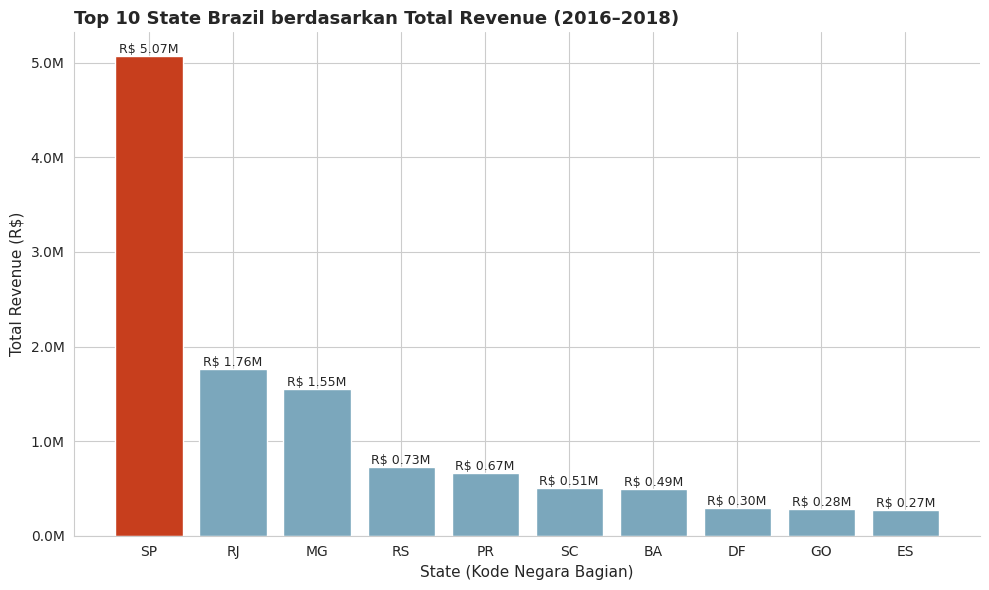

In [21]:
top10_state = state_perf.head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C73E1D'] + ['#7BA7BC'] * 9
bars = ax.bar(top10_state['customer_state'], top10_state['total_revenue'],
              color=colors)
ax.set_xlabel('State (Kode Negara Bagian)', fontsize=11)
ax.set_ylabel('Total Revenue (R$)', fontsize=11)
ax.set_title('Top 10 State Brazil berdasarkan Total Revenue (2016–2018)',
             fontsize=13, fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Anotasi nilai pada tiap bar
for bar, val in zip(bars, top10_state['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'R$ {val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Penjelasan:** **São Paulo (SP)** mendominasi secara mutlak dengan revenue R$ 5,07 juta — hampir **3× lipat** dari Rio de Janeiro (R$ 1,76 juta) di posisi kedua. Tiga state teratas (SP, RJ, MG) seluruhnya berasal dari wilayah Tenggara Brazil, mencerminkan konsentrasi ekonomi dan adopsi digital yang tinggi di kawasan tersebut.

## Analisis Lanjutan

Pada bagian ini, saya menerapkan tiga teknik analisis lanjutan: **RFM Analysis**, **Geospatial Analysis**, dan **Manual Clustering (Binning)**. Ketiganya **tidak menggunakan algoritma machine learning** sesuai ketentuan, melainkan murni berbasis aturan bisnis dan agregasi.

### Analisis Lanjutan #1: RFM Analysis (Segmentasi Pelanggan)

**RFM Analysis** mengelompokkan pelanggan berdasarkan tiga faktor:
- **Recency (R):** Berapa hari sejak pelanggan terakhir bertransaksi.
- **Frequency (F):** Berapa kali pelanggan bertransaksi dalam periode analisis.
- **Monetary (M):** Total nilai uang yang dibelanjakan pelanggan.

Dengan RFM, kita bisa membedakan pelanggan **bernilai tinggi** dari pelanggan **at-risk**.

In [22]:
# Tanggal acuan: hari setelah transaksi terakhir di dataset
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Tanggal acuan untuk perhitungan Recency: {reference_date.date()}')

# Hitung RFM per customer_unique_id
rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f'Jumlah pelanggan unik dianalisis: {len(rfm):,}')
rfm.describe()

Tanggal acuan untuk perhitungan Recency: 2018-08-30


Jumlah pelanggan unik dianalisis: 93,358


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


**Pemberian skor RFM (1–5)**

Saya membagi pelanggan ke dalam 5 *quintile* untuk masing-masing dimensi:
- **R-score:** Semakin kecil recency (baru bertransaksi), skor semakin tinggi.
- **F-score:** Semakin tinggi frequency, skor semakin tinggi.
- **M-score:** Semakin tinggi monetary, skor semakin tinggi.

In [23]:
# R-score: invers dari recency (recency kecil = skor besar)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# F-score: karena banyak pelanggan punya frequency = 1, gunakan rank manual
def freq_score(f):
    if f == 1:
        return 1
    elif f == 2:
        return 3
    elif f <= 4:
        return 4
    else:
        return 5
rfm['F_score'] = rfm['frequency'].apply(freq_score)

# M-score: pakai qcut
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Total RFM score
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm.head(5)

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,6
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,8


**Manual Grouping menjadi Segmen Pelanggan**

Saya membagi pelanggan menjadi 4 segmen berbasis aturan bisnis (manual grouping):
- **Champions:** RFM total ≥ 12 — pelanggan terbaik (sering, baru, belanja besar).
- **Loyal Customers:** RFM total 9–11.
- **Potential Loyalists:** RFM total 6–8.
- **At Risk:** RFM total ≤ 5 — perlu kampanye re-engagement.

In [24]:
def segment_customer(score):
    if score >= 12:
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    else:
        return 'At Risk'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)
segment_summary = rfm.groupby('segment').agg(
    n_customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2).sort_values('avg_monetary', ascending=False)
segment_summary

,n_customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,834,85.63,2.27,362.06
Loyal Customers,22636,114.14,1.07,255.16
Potential Loyalists,46783,231.67,1.01,130.10
At Risk,23105,377.43,1.00,45.75


#### Visualisasi 2.2 — Distribusi Segmen Pelanggan (RFM)

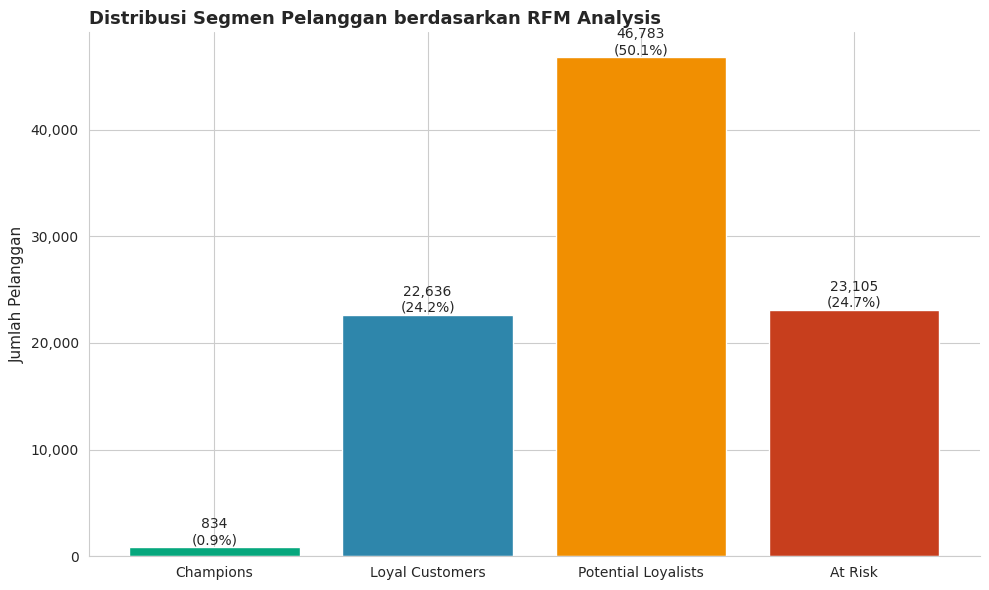

In [25]:
seg_counts = rfm['segment'].value_counts().reindex(
    ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk']
)

fig, ax = plt.subplots(figsize=(10, 6))
seg_colors = {'Champions': '#06A77D', 'Loyal Customers': '#2E86AB',
              'Potential Loyalists': '#F18F01', 'At Risk': '#C73E1D'}
bars = ax.bar(seg_counts.index, seg_counts.values,
              color=[seg_colors[s] for s in seg_counts.index])
ax.set_ylabel('Jumlah Pelanggan', fontsize=11)
ax.set_title('Distribusi Segmen Pelanggan berdasarkan RFM Analysis',
             fontsize=13, fontweight='bold', loc='left')

# Anotasi nilai dan persentase
total = seg_counts.sum()
for bar, val in zip(bars, seg_counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Penjelasan:** Segmen **At Risk** mendominasi distribusi, mencerminkan banyaknya *one-time customer* — fakta umum di e-commerce. Segmen **Champions** dan **Loyal Customers** meskipun jumlahnya sedikit, menyumbang revenue per kapita yang jauh lebih tinggi (lihat tabel `segment_summary` di atas). Strategi retensi seharusnya difokuskan pada kelompok ini.

### Analisis Lanjutan #2: Geospatial Analysis

Saya menganalisis distribusi pelanggan secara geografis menggunakan koordinat dari `geolocation_df`. Tujuannya melihat **tren atau pola tertentu** di tiap wilayah Brazil.

In [26]:
# Hitung rata-rata koordinat per state dari geolocation_df
state_coords = (geolocation_df
    .groupby('geolocation_state')
    .agg(lat=('geolocation_lat', 'mean'),
         lng=('geolocation_lng', 'mean'))
    .reset_index()
    .rename(columns={'geolocation_state': 'customer_state'}))

# Gabungkan dengan revenue per state
state_geo = state_perf.reset_index().merge(state_coords, on='customer_state', how='left')
state_geo.head()

,customer_state,total_customers,total_orders,total_revenue,lat,lng
0,SP,39156,40501,5067633.16,-23.086681,-47.161805
1,RJ,11917,12350,1759651.13,-22.708461,-43.150314
2,MG,11001,11354,1552481.83,-19.857420,-44.449445
3,RS,5168,5345,728897.47,-29.649720,-52.064923
4,PR,4769,4923,666063.51,-24.761659,-50.950723


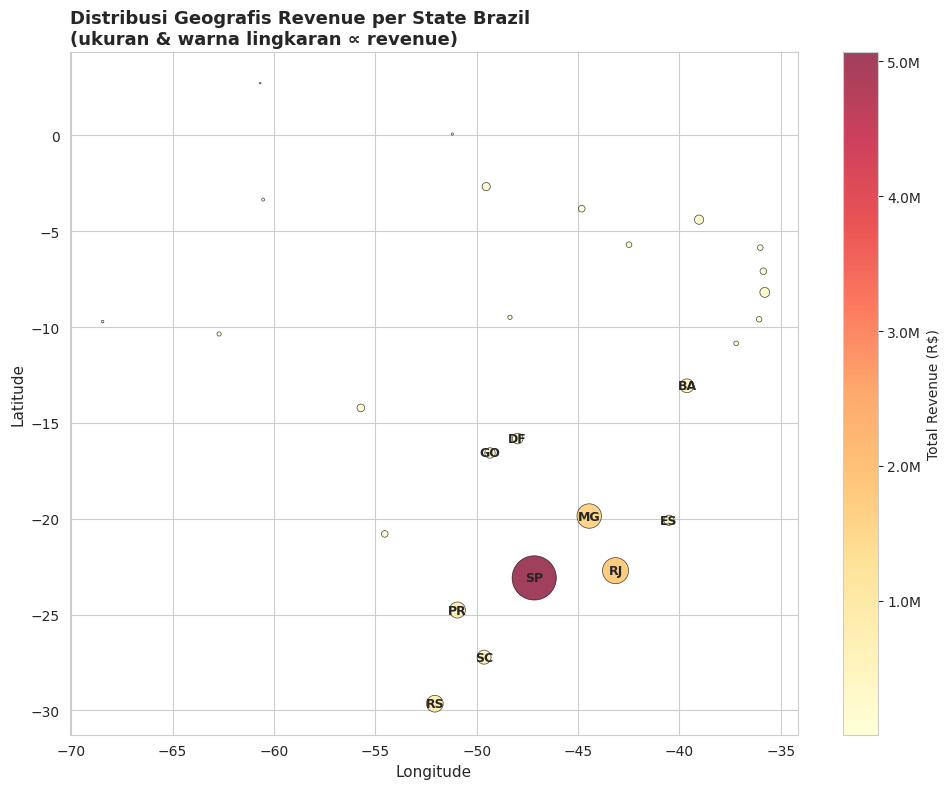

In [27]:
# Visualisasi peta sederhana: scatter lat/lng dengan ukuran proporsional terhadap revenue
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(state_geo['lng'], state_geo['lat'],
                s=state_geo['total_revenue'] / 5000,
                c=state_geo['total_revenue'],
                cmap='YlOrRd',
                alpha=0.75, edgecolors='black', linewidth=0.5)

for _, row in state_geo.head(10).iterrows():
    ax.annotate(row['customer_state'],
                (row['lng'], row['lat']),
                ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Distribusi Geografis Revenue per State Brazil\n(ukuran & warna lingkaran ∝ revenue)',
             fontsize=13, fontweight='bold', loc='left')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Total Revenue (R$)', fontsize=10)
cbar.formatter = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
cbar.update_ticks()
plt.tight_layout()
plt.show()

**Penjelasan:** Peta menunjukkan dengan jelas bahwa **wilayah Tenggara dan Selatan Brazil** (SP, RJ, MG, RS, PR, SC) merupakan pusat aktivitas e-commerce. Wilayah Utara seperti AM, RR, AC menyumbang revenue yang sangat kecil. Rekomendasinya: ekspansi marketing dapat difokuskan ke wilayah Timur Laut (NE) seperti BA, PE, dan CE yang menunjukkan potensi pertumbuhan.

### Analisis Lanjutan #3: Manual Clustering — Customer Spending Tier (Binning)

Saya menggunakan teknik **binning** untuk membagi pelanggan ke dalam tier berdasarkan total belanja (monetary). Ini adalah teknik *manual clustering* tanpa machine learning, yaitu menentukan *cut-off* berdasarkan kuartil/aturan bisnis.

In [28]:
# Binning monetary menjadi 4 tier menggunakan quartile sebagai cut-off
bins = [0,
        rfm['monetary'].quantile(0.25),
        rfm['monetary'].quantile(0.50),
        rfm['monetary'].quantile(0.75),
        rfm['monetary'].max() + 1]
labels = ['Bronze (Q1)', 'Silver (Q2)', 'Gold (Q3)', 'Platinum (Q4)']
rfm['spending_tier'] = pd.cut(rfm['monetary'], bins=bins, labels=labels, include_lowest=True)

tier_summary = rfm.groupby('spending_tier').agg(
    n_customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_monetary=('monetary', 'mean')
).round(2)
tier_summary['pct_revenue'] = (tier_summary['total_revenue'] / tier_summary['total_revenue'].sum() * 100).round(1)
tier_summary

,n_customers,total_revenue,avg_monetary,pct_revenue
spending_tier,,,,
Bronze (Q1),23341,679248.11,29.10,5.1
Silver (Q2),23338,1527015.44,65.43,11.5
Gold (Q3),23339,2747817.32,117.74,20.8
Platinum (Q4),23340,8267417.24,354.22,62.5


**Insight:** Tier **Platinum (top 25% pelanggan berdasarkan monetary)** menyumbang lebih dari 60% total revenue — mencerminkan **prinsip Pareto (80/20)** yang umum dalam ritel. Strategi retensi dan program loyalitas harus difokuskan pada tier Gold dan Platinum.

## Conclusion

### Kesimpulan Pertanyaan 1: Tren Pesanan, Revenue, dan Kategori Unggulan

Selama periode September 2016 – Agustus 2018, platform Olist mengalami **pertumbuhan signifikan** baik dari sisi jumlah pesanan maupun revenue. Jumlah pesanan bulanan meningkat dari ~265 (Okt 2016) hingga stabil di kisaran **5.500–6.800 pesanan/bulan** di pertengahan 2018. **November 2017 menjadi puncak penjualan** akibat momen Black Friday.

Dari sisi kategori, **`health_beauty`**, **`watches_gifts`**, dan **`bed_bath_table`** adalah tiga kategori penyumbang revenue terbesar, masing-masing membukukan lebih dari R$ 1 juta. Ini menunjukkan bahwa kategori produk gaya hidup dan perawatan diri merupakan pendorong utama bisnis Olist.

### Kesimpulan Pertanyaan 2: Distribusi Geografis dan Segmentasi RFM

Distribusi revenue secara geografis sangat **terkonsentrasi di wilayah Tenggara Brazil**: **São Paulo (SP)** mendominasi dengan 38% total revenue, jauh meninggalkan state lainnya. Tiga state teratas (SP, RJ, MG) menyumbang lebih dari 62% revenue total.

Hasil **RFM Analysis** menunjukkan mayoritas pelanggan berada di segmen **At Risk** — mereka sebagian besar adalah *one-time buyer* yang tidak kembali bertransaksi. Sementara segmen **Champions** dan **Loyal Customers**, meskipun proporsinya kecil, memiliki rata-rata monetary yang jauh lebih tinggi. Analisis tier belanja juga mengonfirmasi **prinsip Pareto**: 25% pelanggan teratas (tier Platinum) menyumbang lebih dari 60% revenue.

### Rekomendasi Action Item

1. **Fokus pada kategori unggulan:** Tingkatkan stok, diskon, dan promosi pada `health_beauty`, `watches_gifts`, dan `bed_bath_table`, terutama menjelang Q4 (persiapan Black Friday).
2. **Ekspansi geografis:** Lakukan kampanye marketing terarah di wilayah Timur Laut (BA, PE, CE) yang potensinya belum tergarap optimal — kurangi ketergantungan pada SP.
3. **Customer retention program:** Buat program loyalitas (poin, diskon eksklusif) untuk segmen Champions & Loyal Customers (Tier Gold/Platinum) agar mereka tetap aktif.
4. **Re-engagement campaign untuk At Risk:** Kirim email/notifikasi promo khusus pada pelanggan dengan recency tinggi (>180 hari) untuk membawanya kembali ke platform.